# Clinical question-type distribution: MedQA vs. reader study

Grouped horizontal bars (normalized to %, since totals differ: ~4.9k vs 320) let you compare each question type's share directly across the two sets — the right form for "is the reader study representative of MedQA's mix?". Donut/pie charts are avoided: comparing slices across two circles is hard, and the long tail (prognosis, other) becomes unreadable slivers.

In [1]:
import json, csv, glob, collections
import numpy as np
import matplotlib.pyplot as plt

# --- Clinical question_type label per question_id (MedQA universe) ---
cat = {}
with open("../results/question_categories_cleaned.csv") as f:
    for r in csv.DictReader(f):
        cat[str(r["question_id"])] = r.get("question_type")
medqa = collections.Counter(v for v in cat.values() if v)

# --- Reader study: join its question_ids to the same labels ---
reader = collections.Counter()
for fp in glob.glob("../reader_study/group_*/group_*.json"):
    for it in json.load(open(fp)):
        t = cat.get(str(it["question_id"]))
        if t:
            reader[t] += 1

cats = [c for c, _ in medqa.most_common()]           # order by MedQA share (desc)
n_m, n_r = sum(medqa.values()), sum(reader.values())
m_pct = np.array([100 * medqa[c] / n_m for c in cats])
r_pct = np.array([100 * reader[c] / n_r for c in cats])
print(f"MedQA n={n_m}, reader study n={n_r}")
for c, m, r in zip(cats, m_pct, r_pct):
    print(f"  {c:<12} MedQA {m:4.0f}%   reader {r:4.0f}%")

MedQA n=4855, reader study n=320
  diagnosis    MedQA   57%   reader   48%
  mechanism    MedQA   16%   reader   18%
  treatment    MedQA   15%   reader   22%
  epidemiology MedQA    9%   reader    6%
  prognosis    MedQA    2%   reader    6%
  other        MedQA    1%   reader    0%


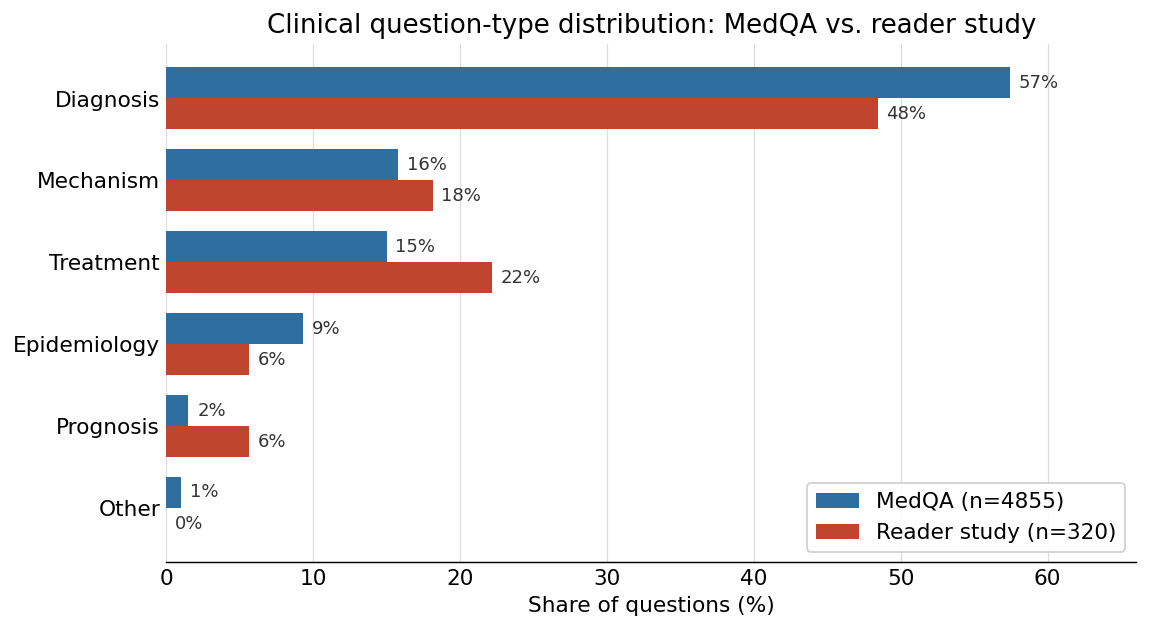

In [2]:
# --- Grouped horizontal bar chart ---
plt.rcParams.update({"font.size": 12, "figure.dpi": 130})
C_MED, C_READ = "#2f6f9f", "#c1442e"   # cool = MedQA, warm = reader study
y = np.arange(len(cats))[::-1]          # highest share on top
h = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.barh(y + h / 2, m_pct, height=h, color=C_MED, zorder=3,
             label=f"MedQA (n={n_m})")
b2 = ax.barh(y - h / 2, r_pct, height=h, color=C_READ, zorder=3,
             label=f"Reader study (n={n_r})")

for bars, vals in [(b1, m_pct), (b2, r_pct)]:
    for bar, v in zip(bars, vals):
        ax.text(v + 0.6, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%",
                va="center", ha="left", fontsize=10, color="#333")

ax.set_yticks(y)
ax.set_yticklabels([c.capitalize() for c in cats])
ax.set_xlabel("Share of questions (%)")
ax.set_xlim(0, max(m_pct.max(), r_pct.max()) * 1.15)
ax.set_title("Clinical question-type distribution: MedQA vs. reader study")
ax.legend(loc="lower right", frameon=True, framealpha=0.9)
ax.grid(axis="x", color="#ddd", lw=0.7, zorder=0)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)

fig.tight_layout()
fig.savefig("../plots/question_type_distribution.png", bbox_inches="tight")
plt.show()

## Composition: MedQA answerable subset (n=2207) vs. reader study (n=320) vs. PubMed answerable subset (n=437)

Both the MedQA and PubMed bars are the **RAG-answerable subset** of their source — questions where agentic retrieval reached `final_sufficient == True` (`results/retrieved_docs_{medqa,pubmed}_qwenagent/*.json`), joined to `question_type` via the matching `question_categories_*_cleaned.csv`. The PubMed set is filtered to diagnosis-only by design (see `pubmed/backup_pre_diagnosis_only/`), so its bar is a single full-width 'diagnosis' segment; labels are LLM-generated. Three 100%-stacked horizontal bars share one fixed category→colour mapping (colour follows the category, never its per-bar rank); each bar's segments are then sorted largest→smallest so every bar reads cleanly on its own. An arrow marks that the reader study is a 320-question stratified subsample drawn *from* the MedQA pool (not an independent set), whereas PubMed is a separate source. A legend carries identity; wide segments are also labelled inline, so identity never rests on colour alone.

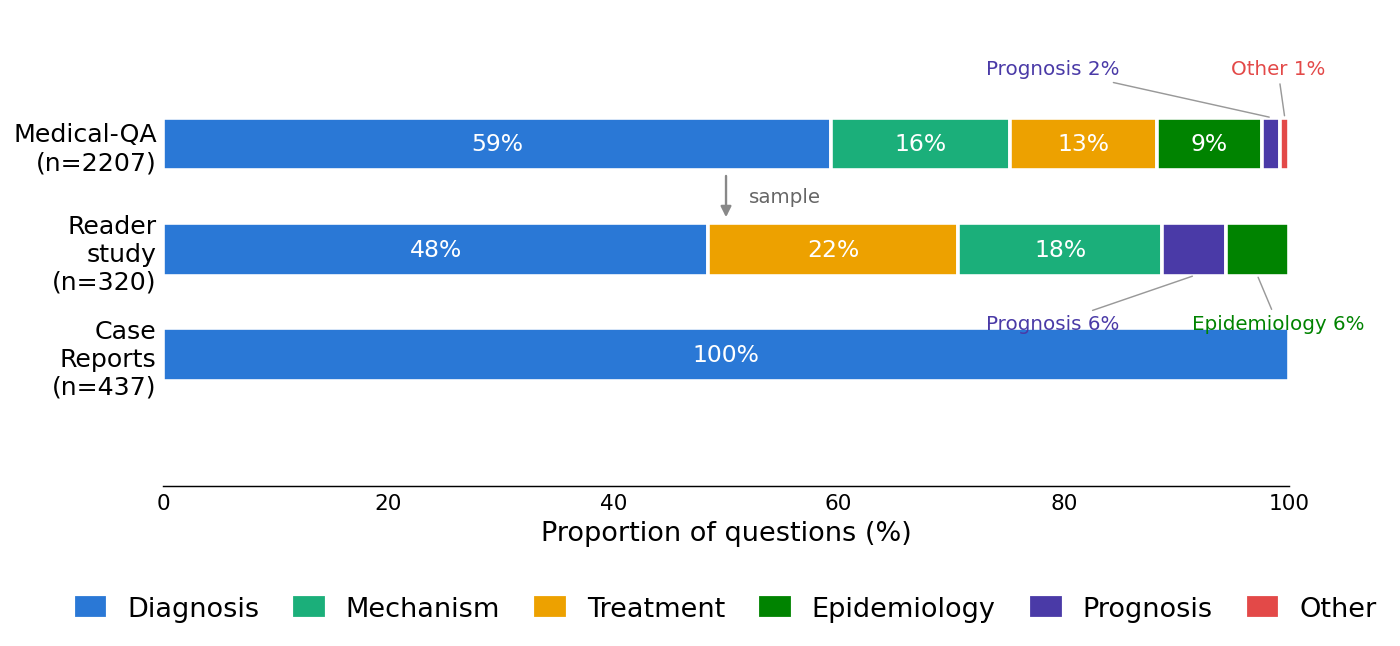

In [6]:
import os
import matplotlib.patches as mpatches


def sufficient_subset(retr_dir, id2type):
    """question_type counts over question_ids whose agentic retrieval reached
    final_sufficient == True (the RAG-answerable subset of a source)."""
    counts = collections.Counter()
    for fn in os.listdir(retr_dir):
        fp = os.path.join(retr_dir, fn)
        if not os.path.isfile(fp):
            continue
        d = json.load(open(fp))
        if d["retrieval_result"]["final_sufficient"] is True:
            t = id2type.get(str(d["question_id"]))
            if t:
                counts[t] += 1
    return counts

# --- MedQA answerable subset: question_ids with sufficient agentic retrieval ---
sub = sufficient_subset("../results/retrieved_docs_medqa_qwenagent", cat)

# --- PubMed answerable subset: same final_sufficient filter, PubMed categories.
# NB: the active set is filtered to diagnosis-only by design (see pubmed/backup_pre_diagnosis_only/),
# so this bar is a single full-width 'diagnosis' segment. Labels are LLM-generated.
catp = {}
with open("../results/question_categories_pubmed_cleaned.csv") as f:
    for r in csv.DictReader(f):
        catp[str(r["question_id"])] = r.get("question_type")
pubmed = sufficient_subset("../results/retrieved_docs_pubmed_qwenagent", catp)

# --- Fixed category -> colour mapping (colour follows the category, never its rank).
# The legend keeps this fixed order; each bar's SEGMENTS are sorted by that bar's own share.
order = [c for c, _ in sub.most_common()]                 # diagnosis, mechanism, ...
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
col = dict(zip(order, PALETTE))                            # category -> colour, fixed

# reader Counter is defined in the cell above (join of reader_study/group_*.json)
DATASETS = [
    (f"Medical-QA\n(n={sum(sub.values())})", sub),
    (f"Reader\nstudy\n(n={sum(reader.values())})", reader),
    (f"Case\nReports\n(n={sum(pubmed.values())})", pubmed),
]

INLINE_THRESH = 6          # segments >= this % are labelled inline; smaller ones get callouts
fig, ax = plt.subplots(figsize=(11, 5.2))
bar_h = 0.5
for y, (name, counter) in enumerate(DATASETS[::-1]):       # top bar = first dataset
    tot = sum(counter.values())
    direction = 1 if y == len(DATASETS) - 1 else -1        # top bar -> callouts above, else below
    bar_order = [c for c, _ in counter.most_common() if c in col]  # sort THIS bar largest -> left
    small = []                                             # (category, pct, midpoint) below threshold
    left = 0.0
    for c in bar_order:
        p = 100 * counter.get(c, 0) / tot
        if p == 0:
            continue
        ax.barh(y, p, left=left, height=bar_h, color=col[c],
                edgecolor="white", linewidth=2, zorder=3)   # 2px surface gap
        if p >= INLINE_THRESH:                              # inline label on wide segments
            ax.text(left + p / 2, y, f"{p:.0f}%", ha="center", va="center",
                    color="white", fontsize=13, fontweight="medium")
        else:
            small.append((c, p, left + p / 2))
        left += p

    # external callouts for slivers too narrow to hold a label, fanned to avoid overlap
    small.sort(key=lambda t: t[2])                          # by midpoint, left -> right
    n = len(small)
    edge = y + direction * bar_h / 2                        # bar edge the leader starts from
    y_lab = y + direction * 0.62
    for i, (c, p, mid) in enumerate(small):
        x_lab = 99 - 20 * (n - 1 - i)                       # rightmost sliver -> rightmost label
        ax.annotate(f"{c.capitalize()} {p:.0f}%", xy=(mid, edge),
                    xytext=(x_lab, y_lab), ha="center",
                    va="bottom" if direction > 0 else "top",
                    fontsize=11, color=col[c], fontweight="medium",
                    annotation_clip=False,
                    arrowprops=dict(arrowstyle="-", color="#999", lw=0.8,
                                    shrinkA=1, shrinkB=1))

ax.set_xlim(0, 100)
ax.set_ylim(-1.25, len(DATASETS) + 0.25)
ax.set_yticks(range(len(DATASETS)))
ax.set_yticklabels([name for name, _ in DATASETS[::-1]], fontsize=14)
ax.set_xlabel("Proportion of questions (%)", fontsize=15)
ax.tick_params(axis="x", labelsize=12)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)

# annotation: the reader study is a stratified subsample drawn FROM MedQA
# (MedQA is the top bar at y=2; reader study is the middle bar at y=1) --
# a straight down-arrow spanning the gap, label set to its right
ax.annotate("", xy=(50, 1.27), xytext=(50, 1.73),
            arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.3),
            annotation_clip=False)
ax.text(52, 1.5, "sample", ha="left", va="center",
        fontsize=11, color="#666")

# legend in fixed category order (identity, not colour-alone)
handles = [mpatches.Patch(color=col[c], label=c.capitalize()) for c in order]
ax.legend(handles=handles, ncol=len(order), loc="upper center",
          bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=15,
          handlelength=1.1, columnspacing=1.3)

fig.tight_layout()
fig.savefig("../plots/question_type.png", bbox_inches="tight")
plt.show()